# Bài 9 — LangGraph cơ bản

## Lý thuyết

### Vấn đề cần giải quyết

Ở Phase 1-2, viết `while True` và `if/else` thủ công để điều khiển luồng chat. Khi hệ thống có **nhiều agent** (Web Agent, RAG Agent, Analysis Agent, Report Agent...) cùng phối hợp, code `if/else` lồng nhau sẽ rất khó quản lý và mở rộng.

**LangGraph** giải quyết việc này bằng cách mô hình hóa luồng xử lý thành một **đồ thị (graph)** - định nghĩa các bước và thứ tự chạy của chúng một cách rõ ràng, dễ debug, dễ thêm bước mới.

### 3 khái niệm cốt lõi

**1. State** - một object (thường là dict hoặc class) chứa **toàn bộ dữ liệu** chạy xuyên suốt graph. Mỗi node nhận state, có thể đọc/sửa nó, rồi truyền tiếp.

> State giống "tờ giấy" truyền tay nhau qua từng bước. Mỗi bước có thể viết thêm thông tin vào tờ giấy đó.

**2. Node** - một **hàm Python** thực hiện 1 việc cụ thể. Nhận state vào, trả về phần state đã được cập nhật.

> Node giống một "trạm xử lý" trên dây chuyền sản xuất.

**3. Edge** - đường nối giữa 2 node, quy định **thứ tự chạy**: sau node A thì chạy đến node B nào.

> Edge giống "băng chuyền" nối giữa các trạm.

### Sơ đồ graph đơn giản nhất

```
   START
     │
     ▼
 ┌────────┐
 │ Input  │   ← nhận dữ liệu đầu vào, lưu vào state
 └───┬────┘
     ▼
 ┌────────┐
 │Process │   ← xử lý dữ liệu trong state
 └───┬────┘
     ▼
 ┌────────┐
 │ Output │   ← in/trả kết quả cuối
 └───┬────┘
     ▼
    END
```

### Các hàm/class quan trọng

| Tên | Ý nghĩa |
|---|---|
| `TypedDict` | Định nghĩa state là 1 dict có các field cụ thể, kiểu rõ ràng — giúp biết trước state có key gì |
| `StateGraph(MyState)` | Tạo "bản thiết kế" graph, dựa trên cấu trúc state đã định nghĩa |
| `graph_builder.add_node(name, func)` | Đăng ký 1 node: tên là `name`, chạy hàm `func` khi đến node này. `func` nhận state, trả về dict các field cần update |
| `graph_builder.add_edge(a, b)` | Nối node `a` → node `b`, nghĩa là chạy xong `a` thì chạy tới `b` |
| `START`, `END` | 2 điểm đặc biệt: điểm bắt đầu và điểm kết thúc graph |
| `graph_builder.compile()` | "Đóng gói" toàn bộ thiết kế thành 1 graph có thể chạy được |
| `graph.invoke(initial_state)` | Chạy graph, bắt đầu với state ban đầu, trả về state cuối cùng |

## Ví dụ hoàn chỉnh

Graph 3 node: `input → process → output`. Mỗi node nhận `state`, có thể đọc các field đã có, và trả về **dict chứa các field mới cần cập nhật** (không cần trả lại toàn bộ state, LangGraph tự gộp vào).

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


class MyState(TypedDict):
    input_text: str
    processed_text: str
    result: str


def input_node(state: MyState):
    print(f"[Input] Nhận: {state['input_text']}")
    return {}


def process_node(state: MyState):
    text = state["input_text"]
    processed = text.upper()  # viết hoa
    print(f"[Process] Đã xử lý: {processed}")
    return {"processed_text": processed}  # cập nhật state


def output_node(state: MyState):
    final = f"Kết quả cuối: {state['processed_text']}"
    print(f"[Output] {final}")
    return {"result": final}

In [4]:
graph_builder = StateGraph(MyState)
graph_builder.add_node("input", input_node)
graph_builder.add_node("process", process_node)
graph_builder.add_node("output", output_node)

graph_builder.add_edge(START, "input")
graph_builder.add_edge("input", "process")
graph_builder.add_edge("process", "output")
graph_builder.add_edge("output", END)

graph = graph_builder.compile()

In [5]:
final_state = graph.invoke({"input_text": "hello world", "processed_text": "", "result": ""})
print("\nState cuối cùng:", final_state)

[Input] Nhận: hello world
[Process] Đã xử lý: HELLO WORLD
[Output] Kết quả cuối: HELLO WORLD

State cuối cùng: {'input_text': 'hello world', 'processed_text': 'HELLO WORLD', 'result': 'Kết quả cuối: HELLO WORLD'}


### Vẽ graph trực quan

LangGraph cho phép xuất graph ra dạng ảnh để nhìn trực quan luồng node/edge, hữu ích khi hệ thống có nhiều agent phức tạp hơn.

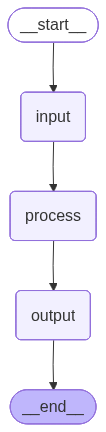

In [6]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## Bài tập

Viết một graph áp dụng cho việc lấy giá cổ phiếu thật, gồm 3 node:

1. Định nghĩa `State` có các field: `symbol` (mã cổ phiếu), `price` (giá), `message` (câu thông báo cuối)
2. Viết 3 node:
   - `fetch_price_node`: dùng `yfinance` lấy giá thật của `state["symbol"]`, lưu vào `price`
   - `analyze_node`: nếu `price > 100` thì set `message = "Giá cao"`, ngược lại `message = "Giá thấp"`
   - `print_node`: in ra `message`
3. Nối graph: `START → fetch_price_node → analyze_node → print_node → END`
4. Chạy graph với `symbol = "NVDA"`

Viết code của bạn vào ô dưới đây:

Import

In [18]:
import yfinance as yf
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

Node

In [19]:
class MyState(TypedDict):
    symbol: str    # mã cổ phiếu
    price: float   # giá
    message: str   # thông báo cuối


def fetch_price_node(state: MyState):
    ticker_obj = yf.Ticker(state["symbol"])
    info = ticker_obj.info
    print(f"Giá hiện tại: {info['currentPrice']}")
    return {"price": info["currentPrice"]}


def analyze_node(state: MyState):
    if state["price"] > 100:
        return {"message": "giá cao"}
    else:
        return {"message": "giá thấp"}


def print_node(state: MyState):
    print(state["message"])
    return {}  # chỉ in ra, không cần cập nhật state


Build graph

In [20]:
graph_builder = StateGraph(MyState)

graph_builder.add_node("fetch_price", fetch_price_node)
graph_builder.add_node("analyze", analyze_node)
graph_builder.add_node("print_result", print_node)

graph_builder.add_edge(START, "fetch_price")
graph_builder.add_edge("fetch_price", "analyze")
graph_builder.add_edge("analyze", "print_result")
graph_builder.add_edge("print_result", END)

graph = graph_builder.compile()


Run graph

In [21]:
final_state = graph.invoke({"symbol": "NVDA", "price": 0.0, "message": ""})
print("State cuối cùng:", final_state)


Giá hiện tại: 207.455
giá cao
State cuối cùng: {'symbol': 'NVDA', 'price': 207.455, 'message': 'giá cao'}
